# Análisis Desagregado: Métricas de Interacción vs Resultado Electoral

Este notebook desagrega el análisis exploratorio por **tipo de interacción**, por **plataforma** y por el **cruce tipo × plataforma**, evaluando qué métrica digital se relaciona mejor con el desempeño electoral en las elecciones de alcaldía de 2023 en Colombia.

**Para cada variante de métrica se calculan:**
1. **Mann–Whitney U**: ¿los ganadores tienen mayor participación % que los no ganadores?
2. **Tasa de acierto del líder digital**: ¿en cuántos municipios el líder en esa métrica fue el ganador? + test binomial vs azar.
3. **R² descompuesto** (pooled, within, between) + OLS con efectos fijos municipales y SE clusterizados.
4. **Robustez logit**: transformación logit(p/100) para verificar la forma funcional.

> ⚠️ **Advertencia composicional**: las participaciones (%) suman 100% dentro de cada municipio, lo que infla el R² pooled. El **R² within** es el estimador honesto.

> ⚠️ **Comparaciones múltiples**: se aplica corrección **FDR (Benjamini-Hochberg) por familias comparables** (agrupando por categoría de métrica). Los resultados son exploratorios.

> ⚠️ **Muestras pequeñas**: las variantes con < 15 municipios se marcan con asterisco (*) en las gráficas. Sus resultados deben interpretarse con cautela.

In [26]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, binom
from scipy.special import logit
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

sns.set_theme(style='whitegrid')
%matplotlib inline
pd.set_option('display.max_columns', None)

## 1. Carga de Datos

In [27]:
base_path = os.getcwd()
resultados_path = os.path.join(base_path, 'resultados')
excel_path = os.path.join(os.path.dirname(base_path), 'Colombia', 'Resultados electorales.xlsx')
csv_unificado = os.path.join(resultados_path, 'redes_unificadas.csv')

df_redes = pd.read_csv(csv_unificado, sep=';', encoding='utf-8-sig')
df_electoral = pd.read_excel(excel_path, sheet_name='Candidatos E-26 ALC')
df_electoral = df_electoral.rename(columns={'ID Candidato': 'id_candidato'})

# Exclusiones
df_redes = df_redes[~df_redes['id_candidato'].str.contains('68547', na=False)]  # Piedecuesta
df_redes = df_redes[~df_redes['id_candidato'].str.contains('68081', na=False)]  # Barrancabermeja
# df_redes = df_redes[~df_redes['id_candidato'].str.contains('11001', na=False)]  # Bogotá

# Merge
df_completo = pd.merge(
    df_redes,
    df_electoral[['id_candidato', 'Candidato', 'Ganador', 'Votos']],
    on='id_candidato',
    how='left'
)

df_completo['DIVIPOLA'] = df_completo['id_candidato'].astype(str).str.split('-').str[1].str.zfill(5)
interact_cols = ['likes', 'comentarios', 'compartidos', 'favoritos']
df_completo['interacciones_totales'] = df_completo[interact_cols].sum(axis=1)

n_munis = df_completo['DIVIPOLA'].nunique()
print(f'Datos cargados: {len(df_completo)} publicaciones, {n_munis} municipios')
print(f'Plataformas: {df_completo["red_social"].unique()}')
print(f'Columnas de interaccion disponibles:')
int_cols = ['likes', 'comentarios', 'compartidos', 'favoritos',
            'fb_haha', 'fb_care', 'fb_wow', 'fb_sad', 'fb_angry']
for c in int_cols:
    if c in df_completo.columns:
        print(f'  + {c}')
    else:
        print(f'  - {c} (no encontrada)')

Datos cargados: 8684 publicaciones, 31 municipios
Plataformas: <StringArray>
['Facebook', 'TikTok', 'Twitter']
Length: 3, dtype: str
Columnas de interaccion disponibles:
  + likes
  + comentarios
  + compartidos
  + favoritos
  + fb_haha
  + fb_care
  + fb_wow
  + fb_sad
  + fb_angry


## 2. Funciones Auxiliares

In [28]:
def prepare_metric_data(df, metric_col, platform_filter=None):
    """
    Agrega por candidato+municipio y calcula participacion % municipal.
    Si platform_filter no es None, filtra primero por esa red social.
    """
    data = df.copy()
    if platform_filter is not None:
        data = data[data['red_social'] == platform_filter]

    agg = data.groupby(['DIVIPOLA', 'id_candidato', 'Candidato', 'Ganador']).agg(
        metric_sum=(metric_col, 'sum'),
        votos=('Votos', 'first'),
        n_posts=(metric_col, 'count')
    ).reset_index()

    total_metric = agg.groupby('DIVIPOLA')['metric_sum'].transform('sum')
    total_votos = agg.groupby('DIVIPOLA')['votos'].transform('sum')

    agg['pct_metric'] = (agg['metric_sum'] / total_metric) * 100
    agg['pct_votos'] = (agg['votos'] / total_votos) * 100

    agg = agg.replace([np.inf, -np.inf], np.nan).dropna(subset=['pct_metric', 'pct_votos'])
    agg = agg[agg.groupby('DIVIPOLA')['metric_sum'].transform('sum') > 0]

    return agg


def r2_decomposition(df, x_col='pct_metric', y_col='pct_votos', group_col='DIVIPOLA'):
    """Descomposicion R2 en pooled, within y between."""
    v = df.dropna(subset=[x_col, y_col]).copy()
    if len(v) < 3:
        return np.nan, np.nan, np.nan

    r2_pooled = np.corrcoef(v[x_col], v[y_col])[0, 1] ** 2

    v['x_dm'] = v[x_col] - v.groupby(group_col)[x_col].transform('mean')
    v['y_dm'] = v[y_col] - v.groupby(group_col)[y_col].transform('mean')
    if v['x_dm'].std() < 1e-10 or v['y_dm'].std() < 1e-10:
        r2_within = np.nan
    else:
        r2_within = np.corrcoef(v['x_dm'], v['y_dm'])[0, 1] ** 2

    means = v.groupby(group_col)[[x_col, y_col]].mean()
    if len(means) < 3 or means[x_col].std() < 1e-10:
        r2_between = np.nan
    else:
        r2_between = np.corrcoef(means[x_col], means[y_col])[0, 1] ** 2

    return r2_pooled, r2_within, r2_between


def ols_fixed_effects(df, x_col='pct_metric', y_col='pct_votos', group_col='DIVIPOLA'):
    """OLS con efectos fijos de municipio y SE clusterizados por DIVIPOLA."""
    v = df.dropna(subset=[x_col, y_col]).copy()
    v[group_col] = v[group_col].astype(str)
    if len(v) < 5 or v[x_col].std() < 1e-10:
        return np.nan, np.nan
    try:
        formula = f'{y_col} ~ {x_col} + C({group_col})'
        model = smf.ols(formula, data=v).fit(
            cov_type='cluster',
            cov_kwds={'groups': v[group_col]}
        )
        return model.params[x_col], model.pvalues[x_col]
    except Exception:
        return np.nan, np.nan


def mann_whitney_pval(df, metric_col='pct_metric', ganador_col='Ganador'):
    """Mann-Whitney U: ganadores vs no ganadores sobre la participacion %."""
    g = df[df[ganador_col] == 'Sí'][metric_col].dropna()
    ng = df[df[ganador_col] == 'No'][metric_col].dropna()
    if len(g) < 2 or len(ng) < 2:
        return np.nan
    _, p = mannwhitneyu(g, ng, alternative='two-sided')
    return p


def leader_accuracy(df, metric_col='pct_metric', ganador_col='Ganador', group_col='DIVIPOLA'):
    """
    Tasa de acierto del lider digital: en cuantos municipios el candidato
    con mayor participacion % en esa metrica fue el ganador.

    Ademas calcula:
    - Tasa esperada por azar: promedio de 1/k por municipio (k = num candidatos).
    - p-valor binomial: P(X >= aciertos_obs | H0: p = p_azar), one-sided.
    """
    idx_max = df.groupby(group_col)[metric_col].idxmax()
    leaders = df.loc[idx_max]
    n_munis = len(leaders)
    n_aciertos = (leaders[ganador_col] == 'Sí').sum()
    tasa = (n_aciertos / n_munis * 100) if n_munis > 0 else np.nan

    # Tasa esperada por azar: promedio de 1/k
    k_per_muni = df.groupby(group_col)[metric_col].count()
    prob_azar = (1 / k_per_muni).mean()
    tasa_azar = prob_azar * 100

    # Test binomial one-sided: P(X >= n_aciertos) bajo H0
    if n_munis > 0 and prob_azar > 0:
        p_binom = binom.sf(n_aciertos - 1, n_munis, prob_azar)
    else:
        p_binom = np.nan

    return n_aciertos, n_munis, tasa, tasa_azar, p_binom


def logit_r2_within(df, x_col='pct_metric', y_col='pct_votos',
                    group_col='DIVIPOLA', eps=1e-3):
    """
    R2 within con transformacion logit en ambos ejes.
    Clip a [eps, 100-eps] antes del logit -- solucion pragmatica
    para manejar ceros y cienes exactos, no una correccion estadistica formal.
    """
    v = df.dropna(subset=[x_col, y_col]).copy()
    if len(v) < 3:
        return np.nan
    v['x_logit'] = logit(v[x_col].clip(eps, 100 - eps) / 100)
    v['y_logit'] = logit(v[y_col].clip(eps, 100 - eps) / 100)
    v['x_dm'] = v['x_logit'] - v.groupby(group_col)['x_logit'].transform('mean')
    v['y_dm'] = v['y_logit'] - v.groupby(group_col)['y_logit'].transform('mean')
    if v['x_dm'].std() < 1e-10 or v['y_dm'].std() < 1e-10:
        return np.nan
    return np.corrcoef(v['x_dm'], v['y_dm'])[0, 1] ** 2


print('Funciones auxiliares cargadas.')

Funciones auxiliares cargadas.


## 3. Nota sobre Terminologia

Es importante distinguir dos conceptos diferentes que usamos en este analisis:

### (a) Cuota / Participacion % (variable continua)
La **participacion porcentual** (`pct_metric`) mide *cuanto* del total de interacciones de un municipio concentra cada candidato. Es una variable continua en [0, 100] y es la que alimenta el R2 within, la regresion OLS y la prueba Mann-Whitney. Responde a: *"El candidato que acapara mas interacciones, tiende a tener mas votos?"*

### (b) Tasa de Acierto del Lider Digital (clasificador winner-take-all)
La **tasa de acierto** mide *con que frecuencia* el candidato con la MAYOR participacion % en una metrica fue el ganador de la eleccion. Es un indicador binario por municipio (acierto/fallo) y equivale a la exactitud de un clasificador ingenuo: *"Predecir que ganara el que tiene mas interacciones."*

> **No son lo mismo.** Un R2 within bajo puede coexistir con una tasa de acierto alta (si la relacion es ruidosa pero el lider suele ser el ganador) y viceversa. Reportamos ambos porque responden a preguntas distintas.

Para evaluar si la tasa de acierto es significativa, la comparamos contra el **azar real**: el promedio de 1/k por municipio (donde k es el numero de candidatos en ese municipio para esa metrica). Un test binomial one-sided evalua si el acierto observado supera al esperado por azar.

## 4. Definicion de Variantes de Metrica

Se analizan **cinco categorias**:
1. **Total (baseline)**: interacciones totales, todas las plataformas.
2. **Tipo cross-platform**: likes, comentarios, compartidos (existen en las tres plataformas).
3. **Por plataforma**: interacciones totales filtradas por red social.
4. **Tipo x Plataforma**: las 9 combinaciones de {likes, comentarios, compartidos} x {Facebook, Twitter, TikTok}.
5. **Especificos de plataforma** : fb_haha, fb_care, fb_wow, fb_sad, fb_angry (solo Facebook) y favoritos (solo TikTok). **NO comparables transversalmente.**

In [29]:
variants = []

# Baseline: todas las interacciones, todas las plataformas
variants.append(dict(name='interacciones_totales', category='Total (baseline)',
                     metric_col='interacciones_totales', platform=None))

# Tipos cross-platform
for col in ['likes', 'comentarios', 'compartidos']:
    variants.append(dict(name=col, category='Tipo cross-platform',
                         metric_col=col, platform=None))

# Totales por plataforma
for plat in ['Facebook', 'Twitter', 'TikTok']:
    variants.append(dict(name=f'Total {plat}', category='Por plataforma',
                         metric_col='interacciones_totales', platform=plat))

# NUEVO: Tipo x Plataforma (9 combinaciones)
for col in ['likes', 'comentarios', 'compartidos']:
    for plat in ['Facebook', 'Twitter', 'TikTok']:
        variants.append(dict(name=f'{col} {plat}', category='Tipo x Plataforma',
                             metric_col=col, platform=plat))

# Tipos especificos de plataforma (NO comparables transversalmente)
for col, plat in [('fb_haha', 'Facebook'), ('fb_care', 'Facebook'),
                  ('fb_wow', 'Facebook'), ('fb_sad', 'Facebook'),
                  ('fb_angry', 'Facebook'), ('favoritos', 'TikTok')]:
    variants.append(dict(name=col, category=f'Especifico {plat}',
                         metric_col=col, platform=plat))

print(f'Variantes a analizar: {len(variants)}')
for v in variants:
    plat_str = f' (filtrado a {v["platform"]})' if v['platform'] else ' (todas)'
    print(f'  - {v["name"]:30s} [{v["category"]:25s}] col={v["metric_col"]}{plat_str}')

Variantes a analizar: 22
  - interacciones_totales          [Total (baseline)         ] col=interacciones_totales (todas)
  - likes                          [Tipo cross-platform      ] col=likes (todas)
  - comentarios                    [Tipo cross-platform      ] col=comentarios (todas)
  - compartidos                    [Tipo cross-platform      ] col=compartidos (todas)
  - Total Facebook                 [Por plataforma           ] col=interacciones_totales (filtrado a Facebook)
  - Total Twitter                  [Por plataforma           ] col=interacciones_totales (filtrado a Twitter)
  - Total TikTok                   [Por plataforma           ] col=interacciones_totales (filtrado a TikTok)
  - likes Facebook                 [Tipo x Plataforma        ] col=likes (filtrado a Facebook)
  - likes Twitter                  [Tipo x Plataforma        ] col=likes (filtrado a Twitter)
  - likes TikTok                   [Tipo x Plataforma        ] col=likes (filtrado a TikTok)
  - comenta

## 5. Ejecucion del Analisis

In [30]:
results = []

for v in variants:
    if v['metric_col'] not in df_completo.columns:
        print(f'  !! Columna {v["metric_col"]} no encontrada, saltando {v["name"]}...')
        continue

    data = prepare_metric_data(df_completo, v['metric_col'], v['platform'])
    n = len(data)
    n_munis_metric = data['DIVIPOLA'].nunique()

    # R2 decomposition
    r2_p, r2_w, r2_b = r2_decomposition(data)

    # OLS con efectos fijos y SE clusterizados
    coef, p_fe = ols_fixed_effects(data)

    # Mann-Whitney U
    p_mw = mann_whitney_pval(data)

    # Acierto del lider digital (antes "dominancia") + baseline de azar
    n_ac, n_m, tasa_ac, tasa_azar, p_binom = leader_accuracy(data)

    # Robustez logit
    r2_logit = logit_r2_within(data)

    results.append({
        'metrica': v['name'],
        'categoria': v['category'],
        'R2_pooled': round(r2_p, 4) if pd.notna(r2_p) else np.nan,
        'R2_within': round(r2_w, 4) if pd.notna(r2_w) else np.nan,
        'R2_between': round(r2_b, 4) if pd.notna(r2_b) else np.nan,
        'R2_within_logit': round(r2_logit, 4) if pd.notna(r2_logit) else np.nan,
        'coef_FE': round(coef, 4) if pd.notna(coef) else np.nan,
        'p_FE_cluster': p_fe if pd.notna(p_fe) else np.nan,
        'acierto_lider': f'{n_ac}/{n_m} ({tasa_ac:.1f}%)',
        'tasa_acierto_lider': round(tasa_ac, 1) if pd.notna(tasa_ac) else np.nan,
        'acierto_esperado_azar': round(tasa_azar, 1) if pd.notna(tasa_azar) else np.nan,
        'p_binomial_vs_azar': p_binom if pd.notna(p_binom) else np.nan,
        'p_MannWhitney': p_mw if pd.notna(p_mw) else np.nan,
        'n': n,
        'n_municipios': n_munis_metric
    })

    r2w_s = f'{r2_w:.4f}' if pd.notna(r2_w) else 'N/A'
    ac_s = f'{tasa_ac:.0f}%' if pd.notna(tasa_ac) else 'N/A'
    print(f'  {v["name"]:30s} | R2w={r2w_s:>8s} | acierto={ac_s:>5s} | munis={n_munis_metric:>3d} | n={n}')

df_results = pd.DataFrame(results)

# --- Bandera de muestra pequena (< 15 municipios) ---
df_results['muestra_pequena'] = df_results['n_municipios'] < 15

# --- Correccion FDR por familias comparables (agrupando por categoria) ---
df_results['p_FDR'] = np.nan
for cat in df_results['categoria'].unique():
    mask_cat = df_results['categoria'] == cat
    p_vals_cat = df_results.loc[mask_cat, 'p_FE_cluster'].values.astype(float)
    valid = ~np.isnan(p_vals_cat)
    if valid.sum() > 1:
        _, p_fdr, _, _ = multipletests(p_vals_cat[valid], method='fdr_bh')
        idx = df_results.index[mask_cat][valid]
        df_results.loc[idx, 'p_FDR'] = np.round(p_fdr, 6)
    elif valid.sum() == 1:
        # Una sola prueba en la familia: FDR = p crudo
        idx = df_results.index[mask_cat][valid]
        df_results.loc[idx, 'p_FDR'] = df_results.loc[idx, 'p_FE_cluster'].round(6).values

# Ordenar por R2 within descendente
df_results = df_results.sort_values('R2_within', ascending=False).reset_index(drop=True)

n_small = df_results['muestra_pequena'].sum()
print()
print(f'Analisis completado. {len(df_results)} variantes evaluadas.')
print(f'{n_small} variantes con muestra pequena (< 15 municipios).')
print(f'FDR aplicado dentro de {df_results["categoria"].nunique()} familias.')

  interacciones_totales          | R2w=  0.3437 | acierto=  71% | munis= 31 | n=120
  likes                          | R2w=  0.3501 | acierto=  71% | munis= 31 | n=120
  comentarios                    | R2w=  0.2278 | acierto=  61% | munis= 31 | n=120
  compartidos                    | R2w=  0.2948 | acierto=  58% | munis= 31 | n=120
  Total Facebook                 | R2w=  0.0705 | acierto=  55% | munis= 31 | n=118
  Total Twitter                  | R2w=  0.3433 | acierto=  46% | munis= 26 | n=75
  Total TikTok                   | R2w=  0.1581 | acierto=  45% | munis= 29 | n=97
  likes Facebook                 | R2w=  0.0699 | acierto=  55% | munis= 31 | n=118
  likes Twitter                  | R2w=  0.3564 | acierto=  46% | munis= 26 | n=75
  likes TikTok                   | R2w=  0.1505 | acierto=  45% | munis= 29 | n=97
  comentarios Facebook           | R2w=  0.0733 | acierto=  55% | munis= 31 | n=118
  comentarios Twitter            | R2w=  0.2899 | acierto=  40% | munis= 25 | n=

## 6. Tabla Resumen

In [31]:
display_cols = ['metrica', 'categoria', 'R2_pooled', 'R2_within', 'R2_between',
                'R2_within_logit', 'coef_FE', 'p_FE_cluster', 'p_FDR',
                'acierto_lider', 'acierto_esperado_azar', 'p_binomial_vs_azar',
                'p_MannWhitney', 'n', 'n_municipios', 'muestra_pequena']

df_display = df_results[display_cols].copy()

# Formato legible para p-valores
for pcol in ['p_FE_cluster', 'p_FDR', 'p_MannWhitney', 'p_binomial_vs_azar']:
    df_display[pcol] = df_display[pcol].apply(
        lambda x: f'{x:.2e}' if pd.notna(x) and x < 0.001 else (f'{x:.4f}' if pd.notna(x) else '-')
    )

df_display

,metrica,categoria,R2_pooled,R2_within,R2_between,R2_within_logit,coef_FE,p_FE_cluster,p_FDR,acierto_lider,acierto_esperado_azar,p_binomial_vs_azar,p_MannWhitney,n,n_municipios,muestra_pequena
0,likes Twitter,Tipo x Plataforma,0.6197,0.3564,1.0,0.4848,0.4565,2.17e-05,1.95e-04,12/26 (46.2%),47.9,0.6457,4.67e-04,75,26,False
1,likes,Tipo cross-platform,0.4750,0.3501,1.0,0.3002,0.4496,3.59e-05,1.01e-04,22/31 (71.0%),30.3,3.74e-06,3.52e-09,120,31,False
2,interacciones_totales,Total (baseline),0.4699,0.3437,1.0,0.2987,0.4468,2.56e-05,2.60e-05,22/31 (71.0%),30.3,3.74e-06,8.04e-09,120,31,False
3,Total Twitter,Por plataforma,0.6136,0.3433,1.0,0.4854,0.4532,1.05e-05,3.20e-05,12/26 (46.2%),47.9,0.6457,5.13e-04,75,26,False
4,compartidos,Tipo cross-platform,0.4302,0.2948,1.0,0.2673,0.4231,8.27e-05,1.01e-04,18/31 (58.1%),30.3,0.0012,7.05e-08,120,31,False
5,comentarios Twitter,Tipo x Plataforma,0.5543,0.2899,1.0,0.3659,0.4174,4.41e-04,0.0013,10/25 (40.0%),45.8,0.7834,0.0025,74,25,False
6,compartidos Twitter,Tipo x Plataforma,0.5698,0.2899,1.0,0.4513,0.4050,2.38e-04,0.0011,11/26 (42.3%),47.9,0.7786,8.73e-04,75,26,False
7,comentarios,Tipo cross-platform,0.3544,0.2278,1.0,0.2702,0.3385,1.01e-04,1.01e-04,19/31 (61.3%),30.3,3.53e-04,7.05e-08,120,31,False
8,comentarios TikTok,Tipo x Plataforma,0.3992,0.2239,1.0,0.0777,0.2919,0.0063,0.0142,16/29 (55.2%),38.3,0.0486,1.81e-04,97,29,False
9,compartidos TikTok,Tipo x Plataforma,0.3814,0.2011,1.0,0.0792,0.2795,0.0103,0.0185,14/29 (48.3%),38.3,0.1802,1.34e-04,97,29,False


## 7. Visualizacion Comparativa

> **Nota interpretativa**: El R2 within mide que tan bien la participacion % del candidato en esa metrica digital predice su participacion % en votos, *controlando por el municipio* (eliminando el artefacto composicional). Valores mas altos indican mayor poder predictivo.
>
> Las metricas marcadas con **asterisco (*)** tienen muestra pequena (< 15 municipios); interpretar con cautela.

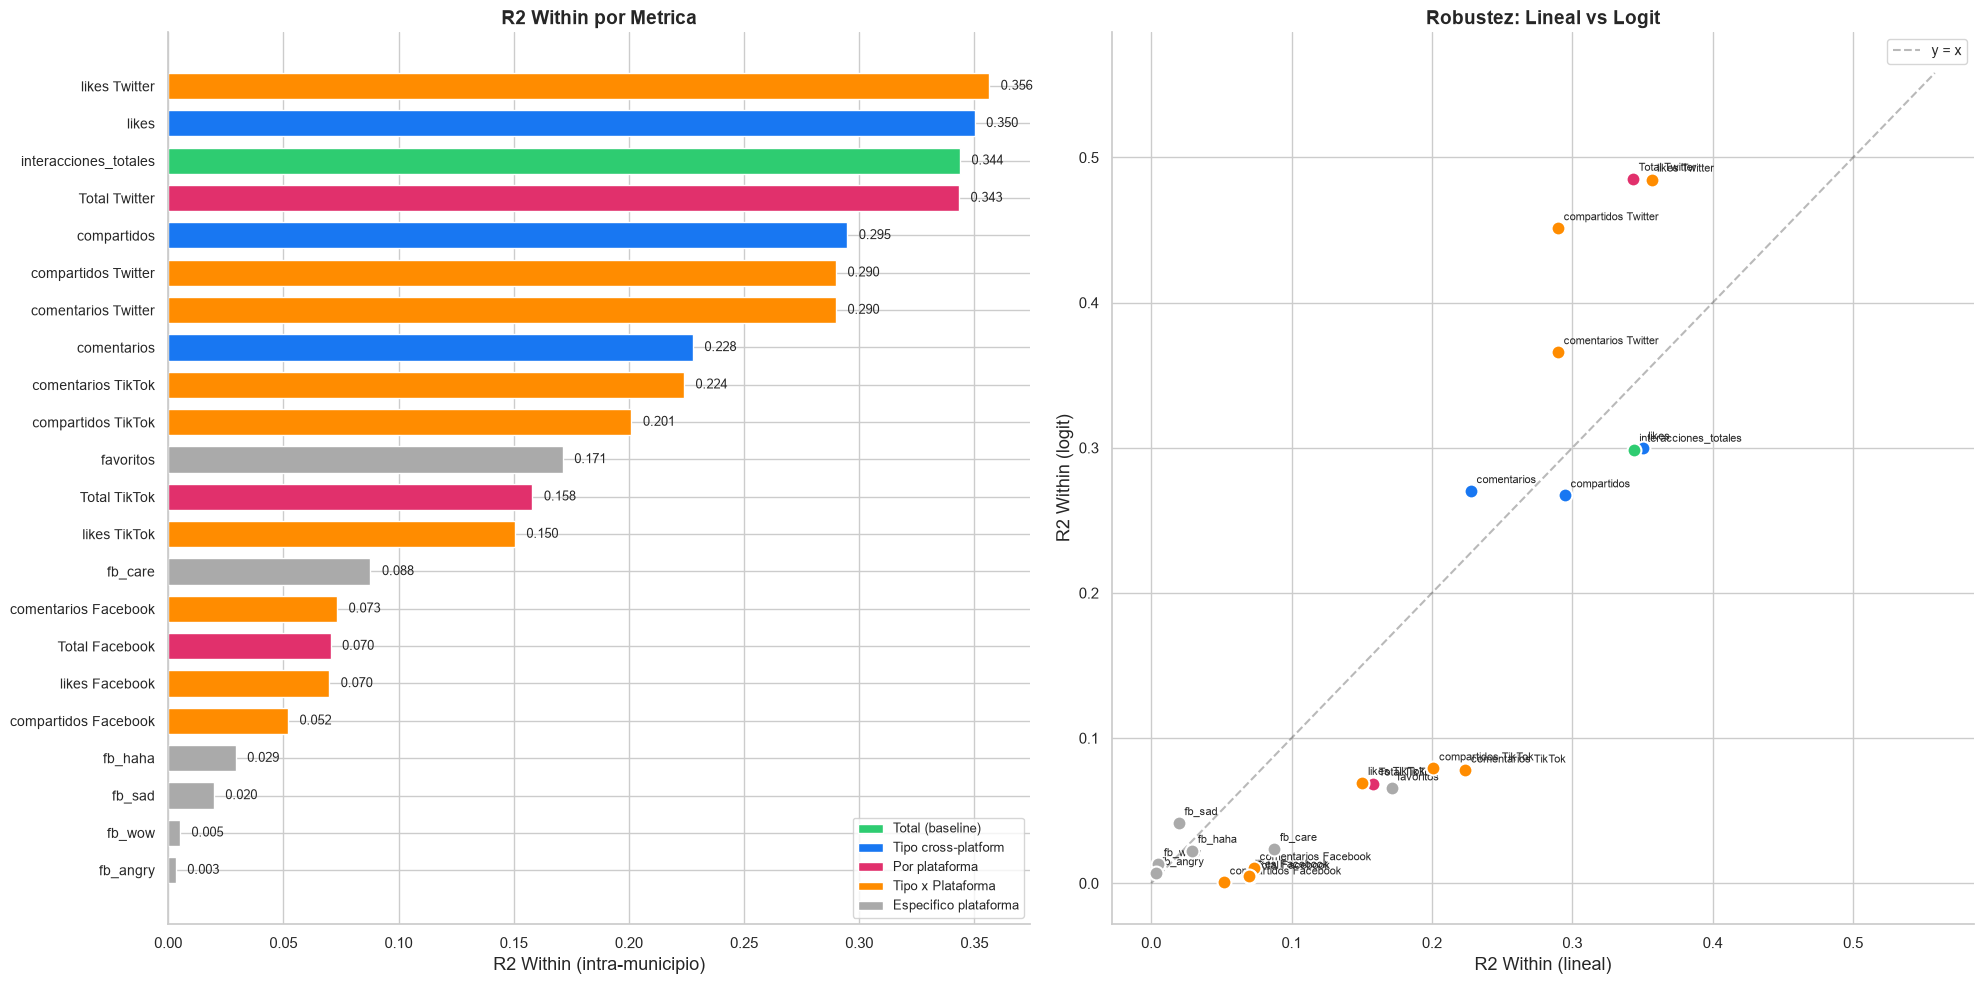

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# ---- Panel 1: R2 within por metrica ----
ax1 = axes[0]
plot_data = df_results.dropna(subset=['R2_within']).sort_values('R2_within')

cat_colors = {
    'Total (baseline)': '#2ecc71',
    'Tipo cross-platform': '#1877F2',
    'Por plataforma': '#E1306C',
    'Tipo x Plataforma': '#FF8C00',
}

colors = [cat_colors.get(c, '#AAAAAA') for c in plot_data['categoria']]

# Etiquetas con asterisco para muestra pequena
labels = [f'{m} *' if mp else m
          for m, mp in zip(plot_data['metrica'], plot_data['muestra_pequena'])]

# Barras con borde punteado para muestra pequena
bars = ax1.barh(range(len(plot_data)), plot_data['R2_within'].values, color=colors,
                edgecolor='white', height=0.7)
for i, (bar, mp) in enumerate(zip(bars, plot_data['muestra_pequena'].values)):
    if mp:
        bar.set_edgecolor('#333333')
        bar.set_linestyle('--')
        bar.set_linewidth(1.5)

ax1.set_yticks(range(len(plot_data)))
ax1.set_yticklabels(labels, fontsize=10)
ax1.set_xlabel('R2 Within (intra-municipio)', fontsize=13)
ax1.set_title('R2 Within por Metrica', fontsize=14, fontweight='bold')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

for bar, val in zip(bars, plot_data['R2_within'].values):
    ax1.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', ha='left', va='center', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in cat_colors.items()]
legend_elements.append(Patch(facecolor='#AAAAAA', label='Especifico plataforma'))
ax1.legend(handles=legend_elements, loc='lower right', fontsize=9, frameon=True)


# ---- Panel 2: Robustez lineal vs logit ----
ax2 = axes[1]
valid = df_results.dropna(subset=['R2_within', 'R2_within_logit'])
scatter_colors = [cat_colors.get(c, '#AAAAAA') for c in valid['categoria']]
markers = ['D' if mp else 'o' for mp in valid['muestra_pequena']]

for _, row in valid.iterrows():
    c = cat_colors.get(row['categoria'], '#AAAAAA')
    m = 'D' if row['muestra_pequena'] else 'o'
    label_text = f'{row["metrica"]} *' if row['muestra_pequena'] else row['metrica']
    ax2.scatter(row['R2_within'], row['R2_within_logit'], s=100, color=c,
                edgecolor='white', linewidth=1.5, zorder=5, marker=m)
    ax2.annotate(label_text, (row['R2_within'], row['R2_within_logit']),
                 fontsize=8, ha='left', va='bottom', xytext=(4, 4),
                 textcoords='offset points')

lim = max(valid['R2_within'].max(), valid['R2_within_logit'].max()) * 1.15
ax2.plot([0, lim], [0, lim], 'k--', alpha=0.3, label='y = x')
ax2.set_xlabel('R2 Within (lineal)', fontsize=13)
ax2.set_ylabel('R2 Within (logit)', fontsize=13)
ax2.set_title('Robustez: Lineal vs Logit', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

un "nowcaster ingenuo" que predice al ganador como "el líder en redes" acierta más del doble que el azar. Sobre una muestra completa de 31 municipios, sin selección.

### Tasa de Acierto del Lider Digital

El diamante (◇) marca la **tasa esperada por azar** (promedio de 1/k por municipio). Las barras que superan su diamante indican metricas donde el lider digital predice al ganador **mejor que el azar**.

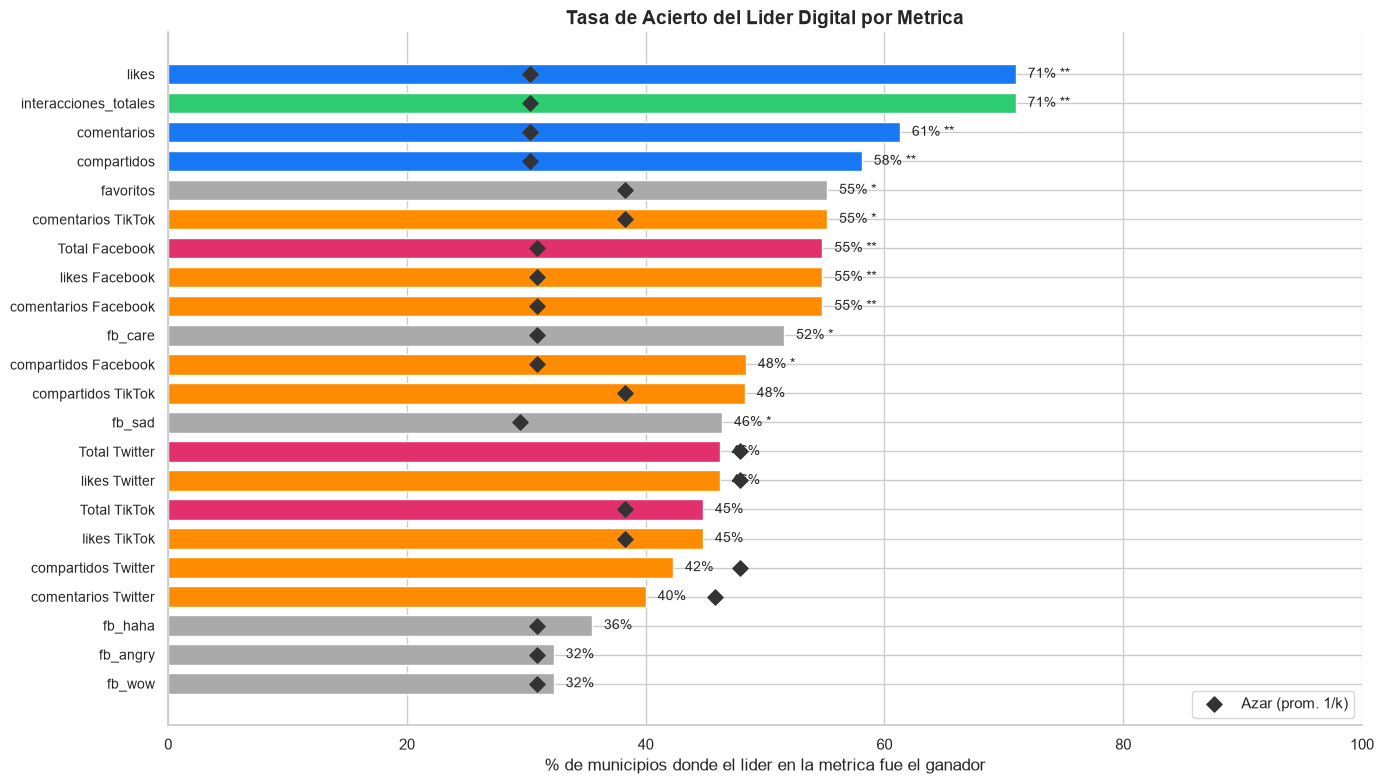

Significancia binomial vs azar: * p<0.05, ** p<0.01


In [33]:
fig, ax = plt.subplots(figsize=(14, 8))

plot_data = df_results.dropna(subset=['tasa_acierto_lider']).sort_values('tasa_acierto_lider')
colors = [cat_colors.get(c, '#AAAAAA') for c in plot_data['categoria']]

labels = [f'{m} *' if mp else m
          for m, mp in zip(plot_data['metrica'], plot_data['muestra_pequena'])]

bars = ax.barh(range(len(plot_data)), plot_data['tasa_acierto_lider'].values,
               color=colors, edgecolor='white', height=0.7)

for i, (bar, mp) in enumerate(zip(bars, plot_data['muestra_pequena'].values)):
    if mp:
        bar.set_edgecolor('#333333')
        bar.set_linestyle('--')
        bar.set_linewidth(1.5)

# Marcadores de azar real por metrica (diamantes)
ax.scatter(plot_data['acierto_esperado_azar'].values, range(len(plot_data)),
           color='#333333', marker='D', s=60, zorder=5, label='Azar (prom. 1/k)')

ax.set_yticks(range(len(plot_data)))
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('% de municipios donde el lider en la metrica fue el ganador', fontsize=12)
ax.set_title('Tasa de Acierto del Lider Digital por Metrica', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, 100)

for bar, val, p_b in zip(bars, plot_data['tasa_acierto_lider'].values,
                          plot_data['p_binomial_vs_azar'].values):
    sig = ''
    if pd.notna(p_b) and p_b < 0.01:
        sig = ' **'
    elif pd.notna(p_b) and p_b < 0.05:
        sig = ' *'
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}%{sig}', ha='left', va='center', fontsize=10)

ax.legend(fontsize=11, loc='lower right')
plt.tight_layout()
plt.show()

print('Significancia binomial vs azar: * p<0.05, ** p<0.01')

## 8. Notas Metodologicas y Limitaciones

### Artefacto composicional
Las participaciones (%) suman 100% dentro de cada municipio. Esto implica que el **R2 pooled siempre sobreestima** la asociacion real. El **R2 within** --obtenido centrando cada variable por su media municipal-- elimina este sesgo y es el estimador honesto que debe reportarse.

### Comparaciones multiples con FDR por familias
Se evaluaron ~22 variantes de metrica. Para controlar falsos positivos, se aplico la correccion **FDR de Benjamini-Hochberg** agrupando por **categoria de metrica** (familia comparable), no globalmente. Esto es porque variantes de distintas categorias operan sobre submuestras diferentes (distinto numero de municipios y candidatos), y mezclarlas en una sola familia seria metodologicamente incorrecto.

### Muestras pequenas
Las variantes marcadas con asterisco (*) tienen datos de < 15 municipios. Sus estimaciones de R2 y tasas de acierto son **menos estables** y no deben compararse directamente con las metricas que cubren los 31 municipios. Las plataformas con menor penetracion (Twitter, TikTok) y las metricas especificas (fb_*, favoritos) suelen caer en esta categoria.

### Tasa de acierto del lider vs azar
La linea base de azar NO es 50% (como seria si solo hubiera 2 candidatos). Es el **promedio de 1/k** por municipio, donde k = numero de candidatos en ese municipio para esa metrica. Con ~3-5 candidatos tipicos, la linea de azar suele estar entre 20-35%. El test binomial one-sided evalua si el acierto observado supera esta linea.

### Metricas especificas de plataforma
- **fb_haha, fb_care, fb_wow, fb_sad, fb_angry**: solo existen para publicaciones de Facebook.
- **favoritos**: solo existe para TikTok.
- Estas metricas **NO deben compararse directamente** con las cross-platform ni entre si.

### Transformacion logit
El clip a [eps, 100-eps] con eps=0.001 antes de logit es una **solucion pragmatica**. Si el R2 within logit difiere mucho del lineal, investigar la distribucion subyacente.

### Errores estandar clusterizados
Todos los SE del modelo OLS con efectos fijos estan **clusterizados por DIVIPOLA**.